In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# чтобы не гуглить, какие номера у ваших букв (первый символ филлерный, чтобы индекс у А был 1
cyrillic_up = [(lambda c: chr(c))(i) for i in range(1039, 1072)]

In [2]:
# index family_letter, name_letter, last_name_letter
F, N, LN = cyrillic_up.index('У'), cyrillic_up.index('Ф'), cyrillic_up.index('А')

# main_function   # functions below needed for fastest gradient method
def func(x, y, z):
    return (x - F) ** 2 * (y - N) ** 2 * (z - LN) ** 2

# derivatives
def dfx(x, y, z):
    return 2 * (x - F) * (y - N) ** 2 * (z - LN) ** 2

def dfy(x, y, z):
    return 2 * (x - F) ** 2 * (y - N) * (z - LN) ** 2

def dfz(x, y, z):
    return 2 * (x - F) ** 2 * (y - N) ** 2 * (z - LN)

def df(x, y, z):
    return np.array([dfx(x, y, z), dfy(x, y, z), dfz(x, y, z)])
    return [dfx(x, y, z), dfy(x, y, z), dfz(x, y, z)]

# derivatives 2nd order
def dfxx(x, y, z):
    return 2 * (y - N) ** 2 * (z - LN) ** 2 
    
def dfyy(x, y, z):
    return 2 * (x - F) ** 2 * (z - LN) ** 2

def dfzz(x, y, z):
    return 2 * (x - F) ** 2 * (y - N) ** 2
# mixed
def dfxy(x, y, z):
    return 4 * (x - F) * (y - N) * (z - LN) ** 2

def dfxz(x, y, z):
    return 4 * (x - F) * (y - N) ** 2 * (z - LN)

def dfyz(x, y, z):
    return 4 * (x - F) ** 2 * (y - N) * (z - LN)
    
# matrix norm
def gessian(x, y, z):
    coords = (x, y, z)
    return [[dfxx(*coords), dfxy(*coords), dfxz(*coords)],
            [dfxy(*coords), dfyy(*coords), dfyz(*coords)],
            [dfxz(*coords), dfyz(*coords), dfzz(*coords)]]
def norm1(x, y, z):
    coords = (x, y, z)
    a = [sum([abs(x) for x in y])
         for y in gessian(*coords)]
    return max(a)
    
def norm(f_values):
    return sum([abs(x) for x in f_values])

# кстати, тут тоже не оптимизировано и вообще работает с ошибками мб (очень важно шаг не ставить меньше 10**5
# (в комменте попробовал написать оптимизированную версию, но чет оно неправильно заработало и я забросил)
def d1_descent(alpha, eps):
    h = 10**5
    x = 0
    f_old = func(*alpha(x))
    while h > 1e-6:
    # for itr in range(10 ** 6):
        
        # f_new = func(*alpha(x+h))
        
        # if itr == 0 and f_old < f_new:
        #     h = -h
            
        # elif f_old < f_new:
        #     h /= 2
        # else:
        #     x += h
        #     f_old = f_new
        # if h <= 1e-6:
            # return x
        
        h /= 2
        # значения альфа (х+аш) слишком большие по сравнению с альфа = коорд - 0* df
        while func(*alpha(x+h)) < func(*alpha(x)):
                x += h
            
        while func(*alpha(x-h)) < func(*alpha(x)):
                x -= h
    return x
        
    

In [3]:
# метод покоординатного спуска
def coordination_descent(func):
    # default initial values
    coords = [0, 0, 0]
    # к сожалению, если не сделать дробный шаг, то мы уйдем в f=0, занулив 1 множитель в функции, поэтому делаем шаг дробным
    h = [1.1] * 3
    eps = [1e-5, 1e-3, 1e-4]
    #table
    columns = ["func_value", "X", "Y", "Z", "hx", "hy", "hz"]
    df = pd.DataFrame(columns=columns)
    eps = [1e-5, 1e-3, 1e-4]
    count = [0, 0, 0]
    fold = func(*coords)
    
    for gl_iter in range(10**8):
        # update pandas table
        new_row = {"func_value": func(*coords), "X": coords[0], "Y": coords[1], "Z": coords[2], "hx": h[0], "hy": h[1], "hz": h[2]}
        df.loc[len(df)] = new_row
        if sum(count) == 3:
            return df
        for idx in range(len(h)):
            
            for itr in range(10**3):
                coords_test = coords.copy()
                coords_test[idx] += h[idx]
                fnew = func(*coords_test)
                
                if gl_iter == 0 and itr == 0:
                    if fold < fnew:
                        h[idx] = -h[idx]

                    else:
                        coords = coords_test.copy()
                        fold = fnew
                        
                elif fold < fnew:
                    if h[idx] <= eps[idx]:
                        count[idx] = 1
                        
                    else:
                        h[idx] /= 2
                        
                    break
                    
                elif fold > fnew:
                    coords = coords_test.copy()
                    fold = fnew
            

    print('Error: Не достигнут К. О.')
    return df



coordination_descent(func)    

,func_value,X,Y,Z,hx,hy,hz
0,1.764000e+05,0.000,0.0000,0.0,1.100000,1.100000,1.100000
1,4.000000e-06,19.800,20.9000,1.1,0.550000,0.550000,0.550000
2,4.000000e-06,19.800,20.9000,1.1,0.275000,0.275000,0.275000
3,5.625000e-07,20.075,20.9000,1.1,0.137500,0.137500,0.137500
4,7.910156e-08,20.075,21.0375,1.1,0.068750,0.068750,0.068750
5,7.910156e-08,20.075,21.0375,1.1,0.034375,0.034375,0.034375
6,7.910156e-08,20.075,21.0375,1.1,0.017188,0.017188,0.017188
7,7.910156e-08,20.075,21.0375,1.1,0.008594,0.008594,0.008594
8,7.910156e-08,20.075,21.0375,1.1,0.004297,0.004297,0.004297
9,7.910156e-08,20.075,21.0375,1.1,0.002148,0.002148,0.002148


In [4]:
def method_of_gradient_fastest_down():
    coords = [0, 0, 0]
    eps = 1e-4
    
    columns = ["func_value", "X", "Y", "Z", "h * 10^5"]
    dg = pd.DataFrame(columns=columns)
    grad = [dfx(*coords), dfy(*coords), dfz(*coords)]
    
    while norm(df(*coords)) / norm1(*coords) > eps:#norm(df(*coords)) / norm1(*coords) > eps:
        alpha = lambda a: (coords - a * df(*coords))
        h = d1_descent(alpha, eps)
        coords = coords - h * df(*coords)
        new_row = {"func_value": func(*coords), "X":coords[0], "Y": coords[1], \
                   "Z": coords[2], "h * 10^5": h * 1e5, "||df|| / ||Hf||": norm(df(*coords)) / \
                   norm1(*coords)}
        dg.loc[len(dg)] = new_row
    return dg

In [5]:
dg = method_of_gradient_fastest_down()
dg

,func_value,X,Y,Z,h * 10^5
0,125.303822,0.051339,0.048894,1.026783,0.291038
1,0.035228,0.051376,0.048929,0.999551,0.291038
2,0.000010,0.051376,0.048929,1.000008,0.291038


C:\Users\R9zhE\AppData\Local\Temp\ipykernel_9460\4000744652.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  func_values = [dg.iloc[i][0] for i in range(ind)]


Text(0, 0.5, 'func value')

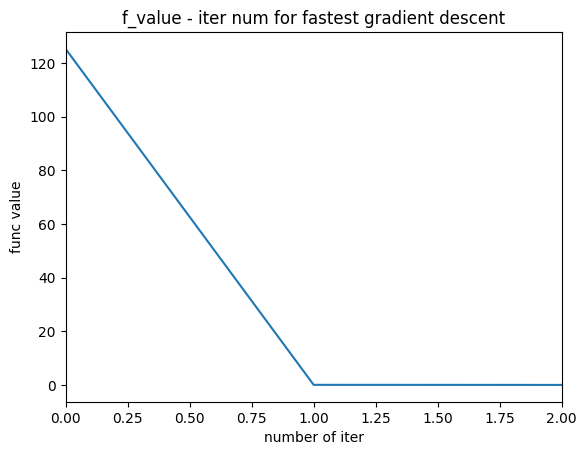

In [6]:
# plot for fastest gradient descent
ind = len(dg)
func_values = [dg.iloc[i][0] for i in range(ind)]
plt.plot([x for x in range(ind)], func_values)
plt.xlim(0, 2)
plt.title('f_value - iter num for fastest gradient descent')
plt.xlabel('number of iter')
plt.ylabel('func value')

In [7]:
# неоптимизированная реализация (по трудоемкости, по ветвлению цикла (шаг может быть только положительным -> 
# можем прибавлять или убавлять, и в целом, логически не оптимизирован (не натянут до предела), 
# но работает верно всегда (даже при целых шагах)
# метод покоординатного спуска
def coordination_descent0(func):
    # default initial values
    coords = [0, 0, 0]
    h = [1] * 3
    eps = [1e-5, 1e-3, 1e-4]
    columns = ["func_value", "X", "Y", "Z", "hx", "hy", "hz"]
    df = pd.DataFrame(columns=columns)
    
    for _ in range(10**5):
        # update pandas table
        new_row = {"func_value": func(*coords), "X": coords[0], "Y": coords[1], "Z": coords[2], "hx": h[0], "hy": h[1], "hz": h[2]}
        df.loc[len(df)] = new_row
        count = 0 # count +=1 if h[i] <= eps[i], if count <3 for one full iteration, then count:=0 again, if count == 3: break
        for i in range(len(h)):
            old_coords = coords.copy()
            coords[i] += h[i]
            # неоптимизировано по вычислению кол-ва вызова функции (трудоемкость)
            if func(*coords) < func(*old_coords):
                while func(*coords) < func(*old_coords):
                    old_coords = coords.copy()
                    coords[i] += h[i]
            else:
                coords[i] -= 2 * h[i]
                if func(*coords) < func(*old_coords):
                    while func(*coords) < func(*old_coords):
                        
                        old_coords = coords.copy()
                        coords[i] -= h[i]
                        
            # уменьшаем шаг или увеличиваем каунт
            if h[i] <= eps[i]:
                count += 1
                
            else: 
                h[i] /= 2

        # критерий остановки
        if count == len(h):
            return df

    print('Error')


In [8]:
coordination_descent0(func)

,func_value,X,Y,Z,hx,hy,hz
0,1.764000e+05,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
1,1.000000e+00,21.000000,22.000000,2.000000,0.500000,0.500000,0.500000
2,1.562500e-02,19.500000,20.500000,0.500000,0.250000,0.250000,0.250000
3,2.441406e-04,20.250000,21.250000,1.250000,0.125000,0.125000,0.125000
4,3.814697e-06,19.875000,20.875000,0.875000,0.062500,0.062500,0.062500
5,5.960464e-08,20.062500,21.062500,1.062500,0.031250,0.031250,0.031250
6,9.313226e-10,19.968750,20.968750,0.968750,0.015625,0.015625,0.015625
7,1.455192e-11,20.015625,21.015625,1.015625,0.007812,0.007812,0.007812
8,2.273737e-13,19.992188,20.992188,0.992188,0.003906,0.003906,0.003906
9,3.552714e-15,20.003906,21.003906,1.003906,0.001953,0.001953,0.001953
